In [ ]:
# Install required libraries
!pip install numpy transformers torch torchvision shap

# Import required libraries
import shap
import torch
import pandas as pd
import numpy as np
from transformers import BertTokenizer, BertModel
import torch.nn as nn

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define the custom MultiTaskModel
class MultiTaskModel(nn.Module):
    def __init__(self):
        super(MultiTaskModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-german-cased')
        self.dropout = nn.Dropout(0.3)
        self.fc_fake_news = nn.Linear(self.bert.config.hidden_size, 1)
        self.fc_hate_speech = nn.Linear(self.bert.config.hidden_size, 1)
        self.fc_toxicity = nn.Linear(self.bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs[1]  # Get the pooled output
        pooled_output = self.dropout(pooled_output)
        fake_news_output = self.fc_fake_news(pooled_output)
        hate_speech_output = self.fc_hate_speech(pooled_output)
        toxicity_output = self.fc_toxicity(pooled_output)
        # Concatenate outputs
        outputs = torch.cat((fake_news_output, hate_speech_output, toxicity_output), dim=1)
        return outputs

# Load the saved model weights
model_path = "/content/multi_task_model.pt"  # Path to the uploaded model file
try:
    model = MultiTaskModel()
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")
    raise

# Load the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-german-cased')

# Load the dataset
dataset_path = "/content/merged_dataset_7jan.csv"  # Path to the uploaded dataset file
try:
    df = pd.read_csv(dataset_path)
    print("Dataset loaded successfully!")
except Exception as e:
    print(f"Error loading dataset: {e}")
    raise

# Select sample texts for SHAP analysis
sample_fake = df[df['is_fake'] == 1].sample(1, random_state=42)
sample_hate = df[df['is_hate_speech'] == 1].sample(1, random_state=42)
sample_toxic = df[df['is_toxic'] == 1].sample(1, random_state=42)
sample_texts = pd.concat([sample_fake, sample_hate, sample_toxic])['text'].tolist()

# Define a model wrapper that accepts raw texts and returns model outputs
def predict_proba(texts):
    # Ensure the input is a list of strings
    if isinstance(texts, str):
        texts = [texts]
    elif isinstance(texts, np.ndarray):
        texts = texts.tolist()  # Convert numpy array to list
    elif not isinstance(texts, list) or not all(isinstance(t, str) for t in texts):
        raise ValueError("Input to predict_proba must be a `str` or `List[str]` of raw text.")

    # Tokenize the texts
    inputs = tokenizer(
        texts, truncation=True, max_length=128, padding=True, return_tensors="pt"
    ).to(device)

    # Get model outputs
    with torch.no_grad():
        outputs = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
    # Apply sigmoid to each output to get probabilities
    fake_news_probs = torch.sigmoid(outputs[:, 0]).cpu().numpy()
    hate_speech_probs = torch.sigmoid(outputs[:, 1]).cpu().numpy()
    toxicity_probs = torch.sigmoid(outputs[:, 2]).cpu().numpy()

    # Stack probabilities into a 2D array (samples x tasks)
    probs = np.column_stack([fake_news_probs, hate_speech_probs, toxicity_probs])
    return probs

# Initialize SHAP explainer
masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_proba, masker)



Using device: cuda


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

<ipython-input-1-215f721fba2d>:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


Model loaded successfully!


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/255k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/485k [00:00<?, ?B/s]

Dataset loaded successfully!


PartitionExplainer explainer: 4it [00:24,  8.08s/it]


Sample 0 SHAP values shape: (55, 3)
Sample 1 SHAP values shape: (16, 3)
Sample 2 SHAP values shape: (63, 3)
Maximum number of features: 63
Padded SHAP values shape: (3, 63, 3)

SHAP Summary Plot for Fake News:


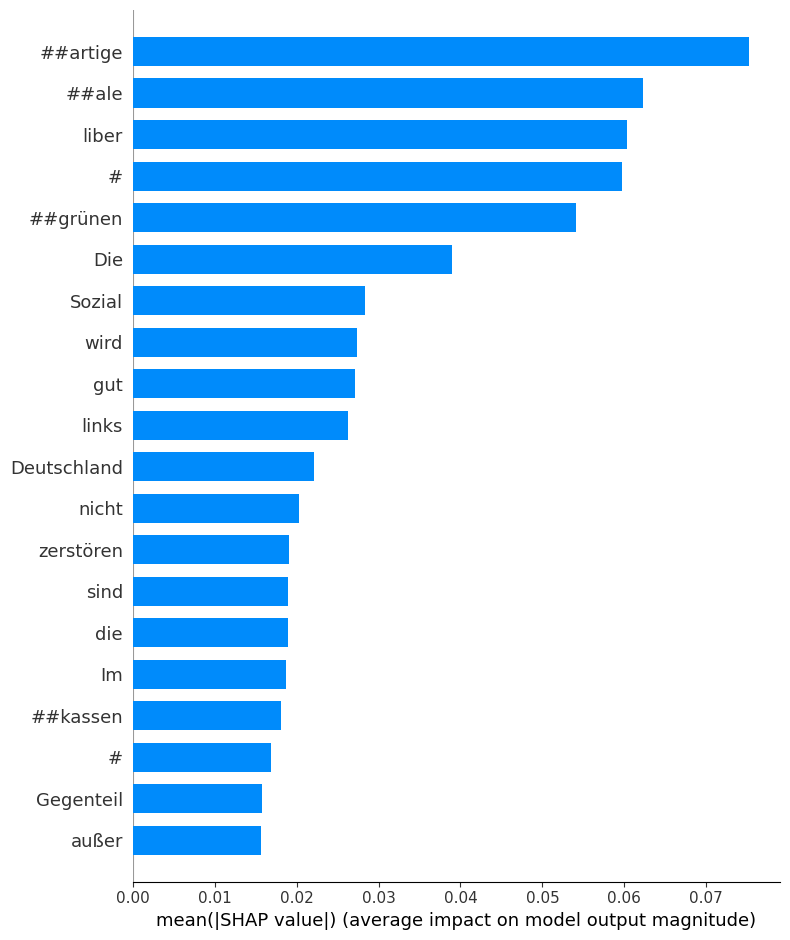


SHAP Summary Plot for Hate Speech:


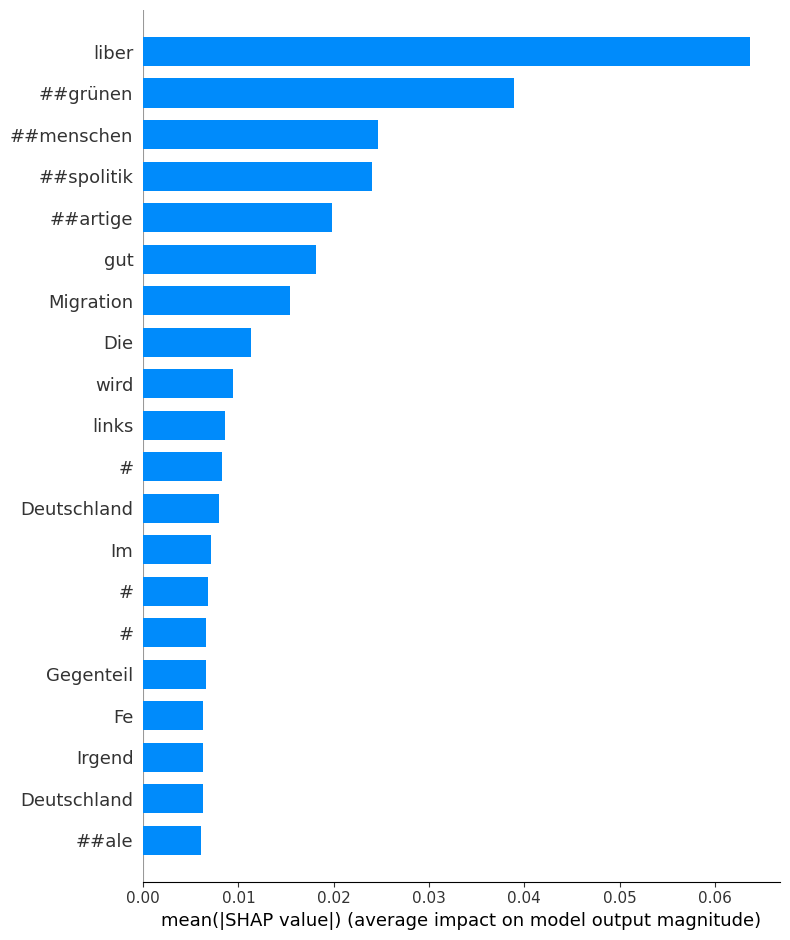


SHAP Summary Plot for Toxicity:


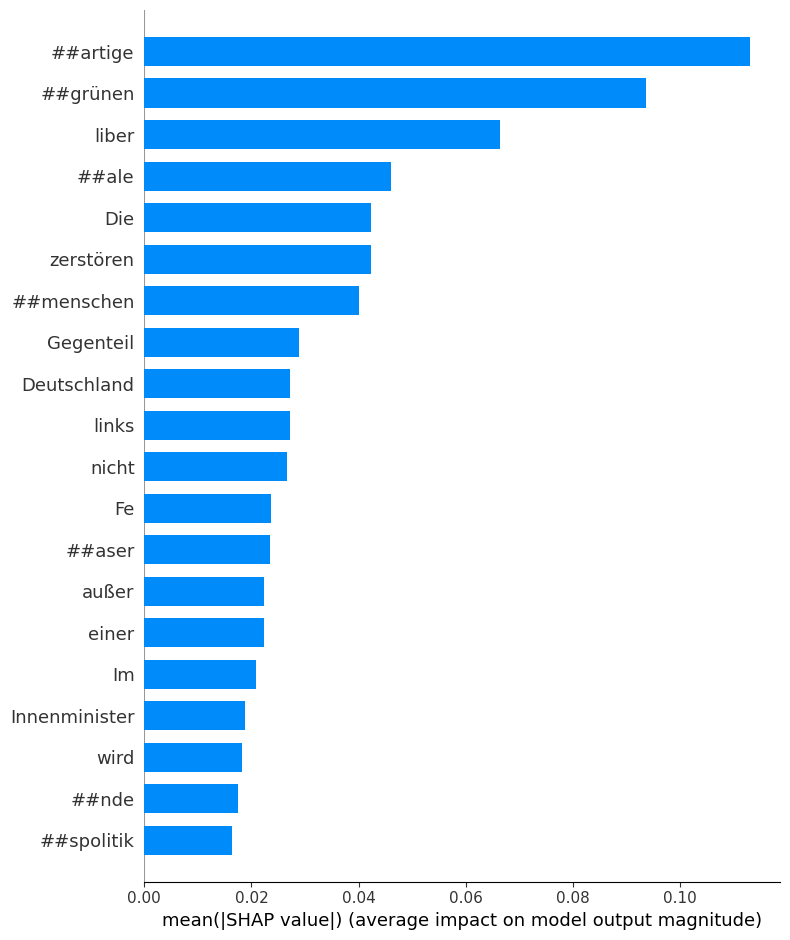

In [ ]:
# Tokenize the sample texts
inputs = tokenizer(sample_texts, padding=True, truncation=True, return_tensors="pt")

# Compute SHAP values
shap_values = explainer(sample_texts)  # Shape: (num_samples, num_features, num_outputs)

# Debug: Check the shape of SHAP values
for i, sample in enumerate(shap_values):
    print(f"Sample {i} SHAP values shape: {sample.values.shape}")

# Find the maximum number of features across all samples
max_features = max(sample.values.shape[0] for sample in shap_values)
print(f"Maximum number of features: {max_features}")

# Pad SHAP values to ensure consistent shapes
padded_shap_values = []
for sample in shap_values:
    num_features = sample.values.shape[0]
    padding_width = ((0, max_features - num_features), (0, 0))  # Pad along the feature dimension
    padded_sample = np.pad(sample.values, padding_width, mode='constant', constant_values=0)
    padded_shap_values.append(padded_sample)

# Convert padded SHAP values to a NumPy array
padded_shap_values = np.array(padded_shap_values, dtype=float)
print(f"Padded SHAP values shape: {padded_shap_values.shape}")

# Visualize SHAP results for each task
for i, task in enumerate(["Fake News", "Hate Speech", "Toxicity"]):
    print(f"\nSHAP Summary Plot for {task}:")

    # Extract SHAP values for the current task (ensure 2D matrix)
    task_shap_values = padded_shap_values[:, :, i]

    # Convert SHAP feature names to strings for the current task
    feature_names = []
    for j in range(len(sample_texts)):
        tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][j].tolist())
        feature_names.append(tokens)

    # Flatten feature_names and pad to match max_features
    feature_names = [token for tokens in feature_names for token in tokens]
    if len(feature_names) < max_features:
        feature_names += ["PAD"] * (max_features - len(feature_names))

    # Generate summary plot for the current task
    shap.summary_plot(
        task_shap_values,  # SHAP values for the i-th task
        features=feature_names[:max_features],  # Ensure it matches the SHAP values
        plot_type="bar"
    )




Sample 0 SHAP data: ['' ' Die' ' links' 'grünen' ' liber' 'ale' ' gut' 'menschen' 'artige'
 ' #' ' Migration' 'spolitik' ' wird' ' #' ' Deutschland' ' nicht'
 ' voran' ' bringen' ' .' ' Im' ' Gegenteil' ' diese' ' wird' ' #'
 ' Deutschland' ' zerstören' ' .' ' #' ' Fe' 'aser' ' ist' ' alles'
 ' außer' ' einer' ' Innenminister' 'in' ' .' ' Irgend' 'wann' ' sind'
 ' die' ' deutschen' ' #' ' Sozial' 'kassen' ' gep' 'lü' 'nde' 'rt' ' .'
 ' #' ' Deutschland' 'ple' 'ite' '']
Sample 0 SHAP values shape: (55, 3)
Sample 1 SHAP data: ['' ' Fe' 'mina' 'zi' 's' ' werden' ' unsere' ' Gesellschaft' ' zerstören'
 ' .' ' Was' ' für' ' ein' ' Betrug' ' !' '']
Sample 1 SHAP values shape: (16, 3)
Sample 2 SHAP data: ['' ' Da' ' darf' ' man' ' nur' ' bei' 'pflichten' ' .' ' .' ' #' ' no'
 'af' 'd' ' #' ' f' 'ck' 'af' 'd' ' #' ' FC' 'K' 'N' 'Z' 'S' ' #' ' Nazis'
 'R' 'aus' ' #' ' gegen' 'rechts' ' #' ' AfD' 'Verb' 'ot' '21' ' #' ' AfD'
 'K' 'eine' 'St' 'immen' ' http' 's' ' :' ' /' ' /' ' t' ' .' ' c' 'o'


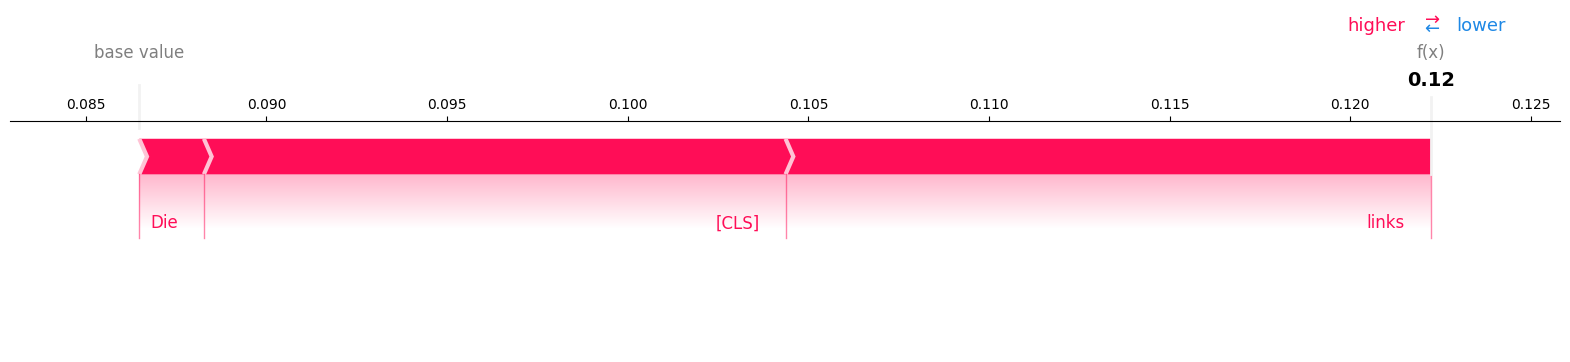

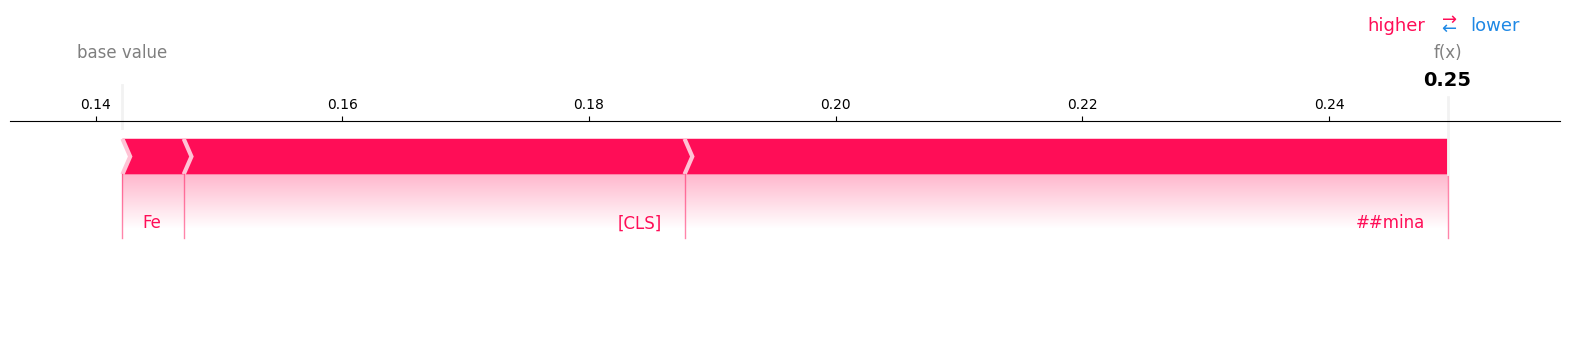

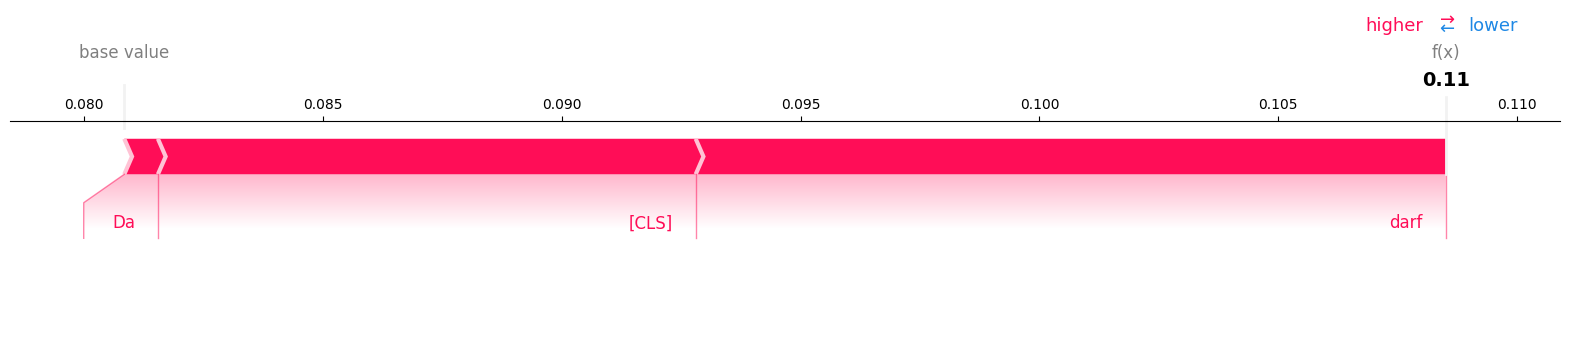

In [ ]:
# Debugging SHAP values and data
for i, sample in enumerate(shap_values):
    print(f"Sample {i} SHAP data: {sample.data}")
    print(f"Sample {i} SHAP values shape: {sample.values.shape}")

# Token-to-feature mapping
for i, input_id in enumerate(inputs["input_ids"]):
    tokens = tokenizer.convert_ids_to_tokens(input_id.tolist())
    print(f"Tokens for Sample {i}: {tokens}")

# Ensure SHAP values align with tokens
for i, text in enumerate(sample_texts):
    valid_data = inputs["input_ids"][i].tolist()  # Directly use input_ids
    features = tokenizer.convert_ids_to_tokens(valid_data)

    # Align features and SHAP values
    feature_values_length = len(shap_values[i].values.mean(axis=0))
    if len(features) < feature_values_length:
        features += ["PAD"] * (feature_values_length - len(features))
    features = features[:feature_values_length]

    # Generate force plot
    shap.force_plot(
        base_value=shap_values[i].base_values.mean(),
        shap_values=shap_values[i].values.mean(axis=0),
        features=features,
        matplotlib=True,
    )
